In [15]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from tqdm import tqdm

In [16]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
 
val_test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [17]:
class MultiLabelSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dirs, class_suffixes, transform=None):
        self.image_dir = image_dir
        self.mask_dirs = mask_dirs
        self.class_suffixes = class_suffixes
        self.image_filenames = sorted([
            f for f in os.listdir(image_dir) if f.endswith(".jpg")
        ])
        self.class_names = list(mask_dirs.keys())
        self.transform = transform
 
    def __len__(self):
        return len(self.image_filenames)
 
    def __getitem__(self, idx):
        image_name = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
 
        h, w, _ = image.shape
        base_name = os.path.splitext(image_name)[0]  # e.g. "IDRiD_01"
        masks = []
 
        for class_name in self.class_names:
            suffix = self.class_suffixes[class_name]           # e.g. "_MA"
            mask_filename = f"{base_name}{suffix}.tif"
            mask_path = os.path.join(self.mask_dirs[class_name], mask_filename)
 
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = (mask > 0).astype(np.uint8)
            else:
                mask = np.zeros((h, w), dtype=np.uint8)
            masks.append(mask)
 
        if self.transform:
            augmented = self.transform(
                image=image,
                masks=masks  # pass list of 2D arrays directly
            )
            image = augmented["image"]                              # [3, H, W]
            mask = torch.stack(augmented["masks"]).float()          # [5, H, W]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(np.stack(masks, axis=0)).float()
 
        return image, mask

In [18]:
BASE = "/Users/poojasrisundaresan/Desktop/Internship/A. Segmentation"
 
train_image_dir = os.path.join(BASE, "1. Original Images/a. Training Set")
test_image_dir  = os.path.join(BASE, "1. Original Images/b. Testing Set")
 
train_mask_base = os.path.join(BASE, "2. All Segmentation Groundtruths/a. Training Set")
test_mask_base  = os.path.join(BASE, "2. All Segmentation Groundtruths/b. Testing Set")
 
mask_subdirs = {
    "Microaneurysms": "1. Microaneurysms",
    "Haemorrhages":   "2. Haemorrhages",
    "HardExudates":   "3. Hard Exudates",
    "SoftExudates":   "4. Soft Exudates",
    "OpticDisc":      "5. Optic Disc"
}
 
class_suffixes = {
    "Microaneurysms": "_MA",
    "Haemorrhages":   "_HE",
    "HardExudates":   "_EX",
    "SoftExudates":   "_SE",
    "OpticDisc":      "_OD"
}
 
train_mask_dirs = {k: os.path.join(train_mask_base, v) for k, v in mask_subdirs.items()}
test_mask_dirs  = {k: os.path.join(test_mask_base,  v) for k, v in mask_subdirs.items()}
 
CLASS_NAMES = list(mask_subdirs.keys())
 
# Weights: rare/small lesions get higher weight, optic disc lowest
# Order: Microaneurysms, Haemorrhages, HardExudates, SoftExudates, OpticDisc
CLASS_WEIGHTS = torch.tensor([3.0, 2.5, 2.0, 2.5, 1.0])

In [19]:
full_train_dataset = MultiLabelSegmentationDataset(
    train_image_dir, train_mask_dirs, class_suffixes, transform=train_transform
)
 
# Quick sanity check — make sure masks are loading correctly
print("=== Mask sanity check (first sample) ===")
sample_img, sample_mask = full_train_dataset[0]
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {int(sample_mask[i].sum().item())} positive pixels")
 
# 80/20 train/val split from the 54 training images
val_size   = int(0.2 * len(full_train_dataset))   # ~11
train_size = len(full_train_dataset) - val_size    # ~43
 
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
 
# Val/test should use val_test_transform, not train_transform with augmentation.
# Since random_split doesn't let us change the transform per subset easily,
# we build a separate val dataset with the correct transform:
val_dataset_clean = MultiLabelSegmentationDataset(
    train_image_dir, train_mask_dirs, class_suffixes, transform=val_test_transform
)
# Use only the val indices from the split
val_indices = val_dataset.indices
val_dataset_clean = torch.utils.data.Subset(val_dataset_clean, val_indices)
 
test_dataset = MultiLabelSegmentationDataset(
    test_image_dir, test_mask_dirs, class_suffixes, transform=val_test_transform
)
 
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset_clean, batch_size=2, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False, num_workers=0)
 
print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset_clean)} | Test: {len(test_dataset)}")

=== Mask sanity check (first sample) ===
  Microaneurysms: 38 positive pixels
  Haemorrhages: 189 positive pixels
  HardExudates: 613 positive pixels
  SoftExudates: 0 positive pixels
  OpticDisc: 1150 positive pixels

Train: 44 | Val: 10 | Test: 27


In [20]:
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.4, beta=0.6, gamma=0.75, smooth=1e-6):
        super().__init__()
        self.alpha = alpha   # weight for false positives
        self.beta  = beta    # weight for false negatives (higher = find more lesions)
        self.gamma = gamma
        self.smooth = smooth
 
    def forward(self, inputs, targets):
        inputs  = torch.sigmoid(inputs)
        inputs  = inputs.reshape(-1)
        targets = targets.reshape(-1)
 
        tp = (inputs * targets).sum()
        fp = ((1 - targets) * inputs).sum()
        fn = (targets * (1 - inputs)).sum()
 
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return (1 - tversky) ** self.gamma

In [21]:
def compute_metrics(outputs, masks, threshold=0.6):
    """
    Returns per-class dice and IoU, plus their means.
    outputs: raw logits [B, C, H, W]
    masks:   binary ground truth [B, C, H, W]
    """
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()
 
    per_class_dice = []
    per_class_iou  = []
 
    for c in range(outputs.shape[1]):
        p = preds[:, c]
        t = masks[:, c]
        intersection = (p * t).sum()
        dice = (2 * intersection + 1e-6) / (p.sum() + t.sum() + 1e-6)
        iou  = (intersection + 1e-6) / (p.sum() + t.sum() - intersection + 1e-6)
        per_class_dice.append(dice.item())
        per_class_iou.append(iou.item())
 
    mean_dice = sum(per_class_dice) / len(per_class_dice)
    mean_iou  = sum(per_class_iou)  / len(per_class_iou)
    return mean_dice, mean_iou, per_class_dice, per_class_iou

In [22]:
def compute_weighted_loss(outputs, masks, loss_fn, class_weights, device):
    """Same loss computation used in both train and val — no inconsistency."""
    weights = class_weights.to(device)
    loss = sum(
        loss_fn(outputs[:, c], masks[:, c]) * weights[c]
        for c in range(outputs.shape[1])
    )
    return loss / weights.sum()
 
 
def train_one_epoch(model, dataloader, optimizer, loss_fn, class_weights, device):
    model.train()
    running_loss, running_dice, running_iou = 0.0, 0.0, 0.0
 
    for images, masks in tqdm(dataloader, desc="Train"):
        images, masks = images.to(device), masks.to(device).float()
        optimizer.zero_grad()
        outputs = model(images)
        loss = compute_weighted_loss(outputs, masks, loss_fn, class_weights, device)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item()
        dice, iou, _, _ = compute_metrics(outputs, masks)
        running_dice += dice
        running_iou  += iou
 
    n = len(dataloader)
    return running_loss / n, running_dice / n, running_iou / n
 
 
@torch.no_grad()
def validate_one_epoch(model, dataloader, loss_fn, class_weights, device):
    model.eval()
    running_loss, running_dice, running_iou = 0.0, 0.0, 0.0
    all_class_dice = [0.0] * 5
    all_class_iou  = [0.0] * 5
 
    for images, masks in tqdm(dataloader, desc="Val  "):
        images, masks = images.to(device), masks.to(device).float()
        outputs = model(images)
        loss = compute_weighted_loss(outputs, masks, loss_fn, class_weights, device)
 
        running_loss += loss.item()
        dice, iou, per_dice, per_iou = compute_metrics(outputs, masks)
        running_dice += dice
        running_iou  += iou
        for c in range(5):
            all_class_dice[c] += per_dice[c]
            all_class_iou[c]  += per_iou[c]
 
    n = len(dataloader)
    avg_class_dice = [x / n for x in all_class_dice]
    avg_class_iou  = [x / n for x in all_class_iou]
    return running_loss / n, running_dice / n, running_iou / n, avg_class_dice, avg_class_iou

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
 
ENCODER = "mit_b0"   # <-- change to "mit_b0" to try transformer encoder
# NOTE: mit_b0 requires: pip install timm
 
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    in_channels=3,
    classes=5,
    activation=None   # raw logits — sigmoid is applied inside loss & metrics
)
model.to(device)
 
loss_fn   = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=0.75).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

Using device: cpu


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

In [24]:
def train_model(model, train_loader, val_loader, optimizer, scheduler,
                loss_fn, class_weights, device, epochs, save_path="best_model.pth"):
    best_val_loss = float('inf')
    history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}
 
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}  (encoder: {ENCODER})")
 
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, loss_fn, class_weights, device
        )
        val_loss, val_dice, val_iou, class_dice, class_iou = validate_one_epoch(
            model, val_loader, loss_fn, class_weights, device
        )
 
        scheduler.step(val_loss)
 
        print(f"  Train  — loss: {train_loss:.4f}  dice: {train_dice:.4f}  iou: {train_iou:.4f}")
        print(f"  Val    — loss: {val_loss:.4f}  dice: {val_dice:.4f}  iou: {val_iou:.4f}")
        print("  Per-class Val Dice:")
        for name, d, u in zip(CLASS_NAMES, class_dice, class_iou):
            print(f"    {name:20s}  dice: {d:.4f}  iou: {u:.4f}")
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model → {save_path}")
 
    return history
 
 
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=loss_fn,
    class_weights=CLASS_WEIGHTS,
    device=device,
    epochs=50,
    save_path=f"best_{ENCODER}.pth"
)


Epoch 1/50  (encoder: mit_b0)


Val  : 100%|██████████| 5/5 [00:02<00:00,  2.44it/s]


  Train  — loss: 0.9834  dice: 0.0240  iou: 0.0124
  Val    — loss: 0.9860  dice: 0.0265  iou: 0.0138
  Per-class Val Dice:
    Microaneurysms        dice: 0.0011  iou: 0.0005
    Haemorrhages          dice: 0.0074  iou: 0.0037
    HardExudates          dice: 0.0245  iou: 0.0124
    SoftExudates          dice: 0.0000  iou: 0.0000
    OpticDisc             dice: 0.0997  iou: 0.0525
  ✓ Saved best model → best_mit_b0.pth

Epoch 2/50  (encoder: mit_b0)


Val  : 100%|██████████| 5/5 [00:02<00:00,  2.43it/s]


  Train  — loss: 0.9803  dice: 0.0370  iou: 0.0195
  Val    — loss: 0.9825  dice: 0.0486  iou: 0.0264
  Per-class Val Dice:
    Microaneurysms        dice: 0.0035  iou: 0.0018
    Haemorrhages          dice: 0.0144  iou: 0.0073
    HardExudates          dice: 0.0350  iou: 0.0179
    SoftExudates          dice: 0.0000  iou: 0.0000
    OpticDisc             dice: 0.1902  iou: 0.1052
  ✓ Saved best model → best_mit_b0.pth

Epoch 3/50  (encoder: mit_b0)


...

  Train  — loss: 0.7467  dice: 0.4204  iou: 0.3348
  Val    — loss: 0.7904  dice: 0.3945  iou: 0.3186
  Per-class Val Dice:
    Microaneurysms        dice: 0.0096  iou: 0.0048
    Haemorrhages          dice: 0.2632  iou: 0.1575
    HardExudates          dice: 0.3709  iou: 0.2334
    SoftExudates          dice: 0.4049  iou: 0.3378
    OpticDisc             dice: 0.9241  iou: 0.8592

Epoch 49/50  (encoder: mit_b0)


Val  : 100%|██████████| 5/5 [00:02<00:00,  2.38it/s]


  Train  — loss: 0.7182  dice: 0.4528  iou: 0.3644
  Val    — loss: 0.7976  dice: 0.3443  iou: 0.2731
  Per-class Val Dice:
    Microaneurysms        dice: 0.0108  iou: 0.0054
    Haemorrhages          dice: 0.2640  iou: 0.1608
    HardExudates          dice: 0.4281  iou: 0.2802
    SoftExudates          dice: 0.0971  iou: 0.0642
    OpticDisc             dice: 0.9217  iou: 0.8550

Epoch 50/50  (encoder: mit_b0)


Val  : 100%|██████████| 5/5 [00:02<00:00,  2.35it/s]

  Train  — loss: 0.7203  dice: 0.4453  iou: 0.3559
  Val    — loss: 0.7737  dice: 0.3672  iou: 0.2815
  Per-class Val Dice:
    Microaneurysms        dice: 0.0106  iou: 0.0053
    Haemorrhages          dice: 0.2740  iou: 0.1660
    HardExudates          dice: 0.4351  iou: 0.2807
    SoftExudates          dice: 0.2369  iou: 0.1704
    OpticDisc             dice: 0.8792  iou: 0.7850
  ✓ Saved best model → best_mit_b0.pth


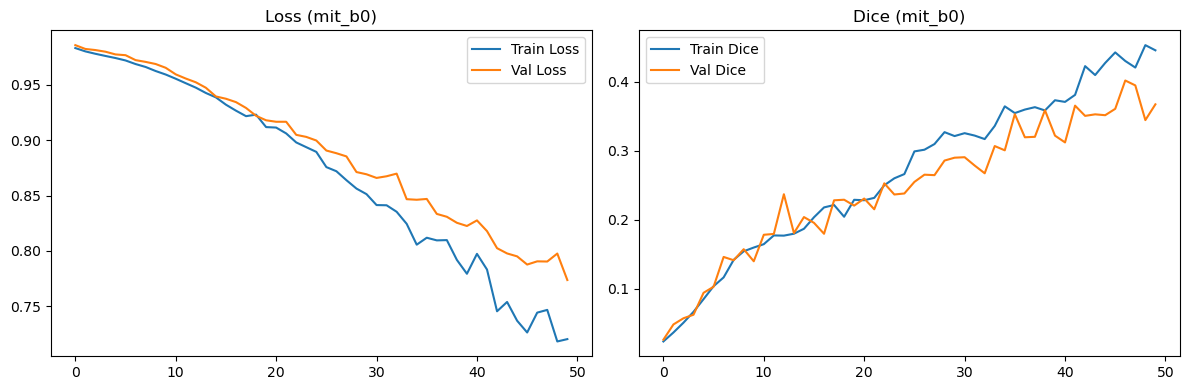

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title(f"Loss ({ENCODER})")
axes[0].legend()
 
axes[1].plot(history["train_dice"], label="Train Dice")
axes[1].plot(history["val_dice"],   label="Val Dice")
axes[1].set_title(f"Dice ({ENCODER})")
axes[1].legend()
 
plt.tight_layout()
plt.savefig(f"training_curves_{ENCODER}.png", dpi=150)
plt.show()

In [26]:
model.load_state_dict(torch.load(f"best_{ENCODER}.pth", map_location=device))
model.eval()
 
test_loss, test_dice, test_iou, class_dice, class_iou = validate_one_epoch(
    model, test_loader, loss_fn, CLASS_WEIGHTS, device
)
 
print(f"\n=== Test Results ({ENCODER}) ===")
print(f"  Loss: {test_loss:.4f}  Mean Dice: {test_dice:.4f}  Mean IoU: {test_iou:.4f}")
print("  Per-class:")
for name, d, u in zip(CLASS_NAMES, class_dice, class_iou):
    print(f"    {name:20s}  dice: {d:.4f}  iou: {u:.4f}")

Val  : 100%|██████████| 14/14 [00:05<00:00,  2.34it/s]


=== Test Results (mit_b0) ===
  Loss: 0.7330  Mean Dice: 0.4132  Mean IoU: 0.3215
  Per-class:
    Microaneurysms        dice: 0.0096  iou: 0.0048
    Haemorrhages          dice: 0.3227  iou: 0.2040
    HardExudates          dice: 0.4339  iou: 0.2893
    SoftExudates          dice: 0.4162  iou: 0.3166
    OpticDisc             dice: 0.8838  iou: 0.7928


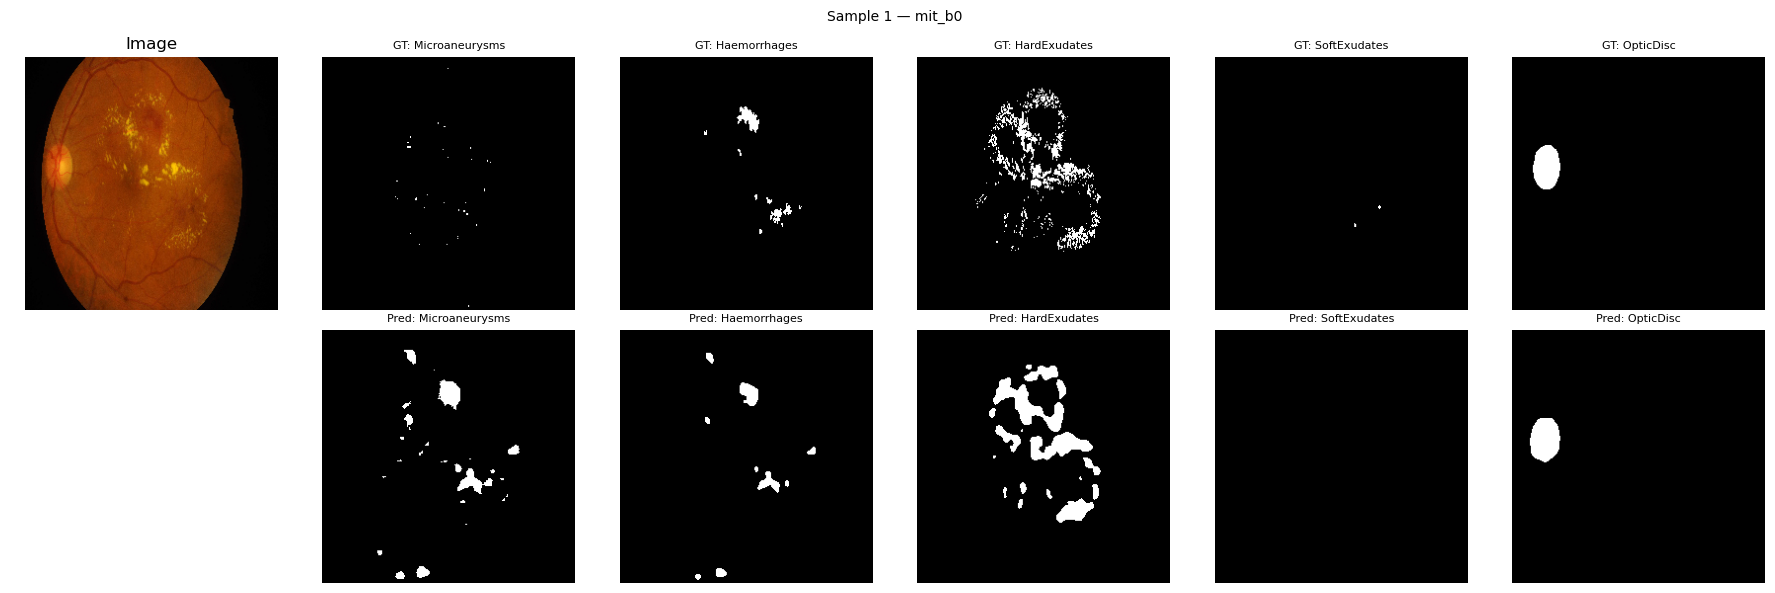

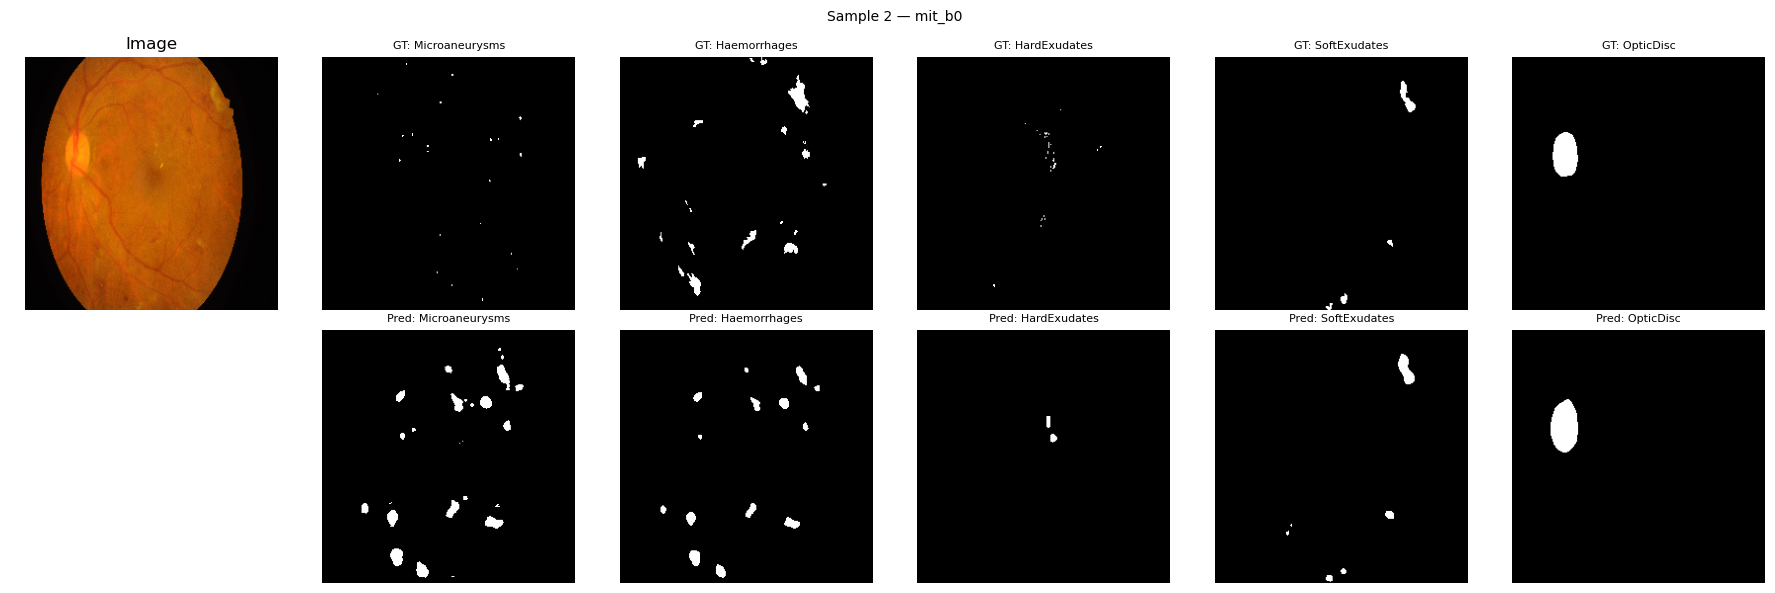

In [27]:
def visualize_predictions(model, dataloader, device, class_names, num_samples=4):
    model.eval()
    images, true_masks = next(iter(dataloader))
    images = images.to(device)
 
    with torch.no_grad():
        outputs = model(images)
        pred_masks = (torch.sigmoid(outputs) > 0.6).cpu()
 
    num_samples = min(num_samples, images.shape[0])
    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        # rough de-normalise for display
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
 
        fig, axes = plt.subplots(2, 6, figsize=(18, 6))
        axes[0, 0].imshow(img); axes[0, 0].set_title("Image"); axes[0, 0].axis("off")
        axes[1, 0].axis("off")
 
        for j, name in enumerate(class_names):
            axes[0, j+1].imshow(true_masks[i][j], cmap="gray")
            axes[0, j+1].set_title(f"GT: {name}", fontsize=8)
            axes[0, j+1].axis("off")
 
            axes[1, j+1].imshow(pred_masks[i][j], cmap="gray")
            axes[1, j+1].set_title(f"Pred: {name}", fontsize=8)
            axes[1, j+1].axis("off")
 
        plt.suptitle(f"Sample {i+1} — {ENCODER}", fontsize=10)
        plt.tight_layout()
        plt.savefig(f"pred_sample_{i+1}_{ENCODER}.png", dpi=150)
        plt.show()
 
visualize_predictions(model, test_loader, device, CLASS_NAMES)